# **MINI PROJECT : BSMS 1306 Introduction to Data Analytics**

## 1. Background of Study
    In modern educational research, student performance is rarely determined by a single factor. Instead, academic achievement is shaped by a combination of family background and environmental influences. The key variables such as parental education levels, school support systems such as subsidized lunch programs and completion of test preparation courses all play a major role in shaping a student's success in core subjects like mathematics, reading and writing. Rather than evaluating exam scores, this study analyzes a dataset containing student records to uncover meaningful trends. By examining how these background charachteristics related, this project aims to understand the relationhip between a student's social environment and their overall ytest performance, providing helpful insight for improving educational support.

## 2. Obejctive of Analysis
* **Data preparation:** To clean and structure the raw student performance dataset by fixing columns, checking for missing values and preparing the data for seamless analysis.
*  **Parental education influence:** To analyze how the level of parental education affects student achievement acress subjects.
*   **Test preparation effectiveness:** To evaluate whether whether completing a test preparation course leads to higher scores compared to those who did not.
*    **Lunch type as socio-economic representative:** To compare performance between students receiving standard lunch vs free lunch to access socio-economic impact.

In [12]:
import pandas as pd

df = pd.read_csv('StudentsPerformance.csv')

print("--- Show First 5 Rows ---")
print(df.head())

print("--- Check Missing Values ---")
print(df.isnull().sum())

math = df['math score']
reading = df['reading score']
writing = df['writing score']

df['average_score'] = (math + reading + writing) / 3

df = df.rename(columns={
    'gender': 'gender',
    'race/ethnicity': 'race_ethnicity',
    'parental level of education': 'parental_level_of_education',
    'lunch': 'lunch',
    'test preparation course': 'test_preparation_course',
    'math score': 'math_score',
    'reading score': 'reading_score',
    'writing_score': 'writing_score'
})

print("--- New Cleaned Data Preview ---")
print(df.head())

df.to_csv('cleaned_students_performance.csv', index=False)
print("Success! The file 'cleaned_students_performance.csv' is saved!")

--- Show First 5 Rows ---
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
--- Check Missing Values ---
gender                         0
race/ethnicity                 0
parental level of education    0
lunch

In [13]:
df['average_score'].agg(['mean','median','max','min'])

mean       67.770667
median     68.333333
max       100.000000
min         9.000000
Name: average_score, dtype: float64

In [22]:
import pandas as pd
DF = pd.read_csv('cleaned_students_performance.csv')
import matplotlib.pyplot as plt

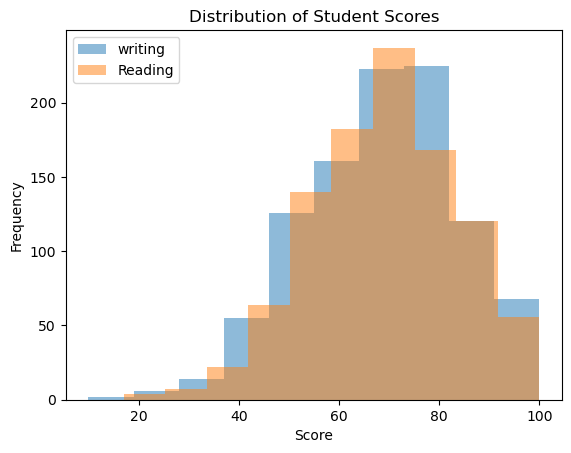

In [34]:
import matplotlib.pyplot as plt

plt.hist(DF['writing score'], bins=10, alpha=0.5, label='writing')
plt.hist(DF['reading_score'], bins=10, alpha=0.5, label='Reading')


plt.title('Distribution of Student Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()

plt.show()

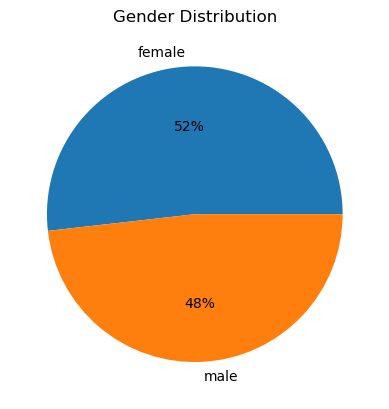

In [28]:
df.groupby('gender').size().plot(
    kind='pie',
    autopct='%1.0f%%'
)

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

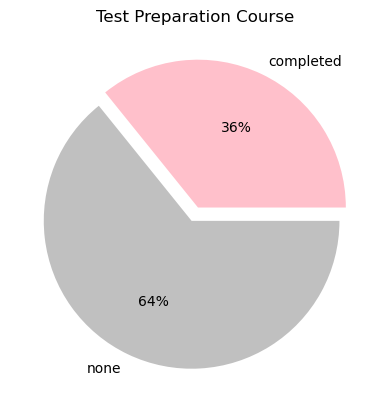

In [29]:
colors = ['pink', 'silver']

explode = (0.05, 0.05)

df.groupby('test_preparation_course').size().plot(
    kind='pie',
    autopct='%1.0f%%',
    colors=colors,
    explode=explode
)

plt.title('Test Preparation Course')
plt.ylabel('')
plt.show()

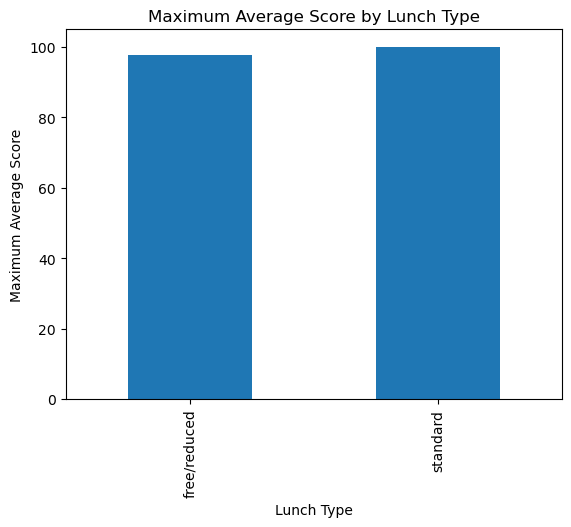

In [30]:

lunch_max = df.groupby('lunch')['average_score'].max()

lunch_max.plot(kind='bar')

plt.title('Maximum Average Score by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Maximum Average Score')
plt.show()

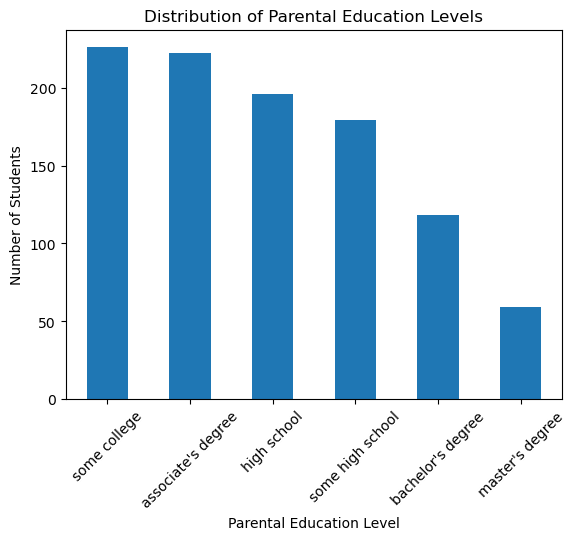

In [35]:


df['parental_level_of_education'].value_counts().plot(kind='bar')

plt.title('Distribution of Parental Education Levels')
plt.xlabel('Parental Education Level')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

st.image(r'C:\Users\welcome\Desktop\BSMS1306\streamlit\h.jpg')
st.image('h.jpg')
st.set_page_config(page_title="Student Performance Dashboard", layout="wide")

st.title("📊 Student Performance Analytics Dashboard")
st.write("Welcome! This interactive dashboard visualizes student performance data based on various demographic factors.")
st.date_input("Select a date")


df = pd.read_csv("cleaned_students_performance.csv")

st.subheader("Raw Data")
st.write(df)

st.subheader("Histogram")
fig, ax = plt.subplots(figsize = (10,6))
ax.hist(df['writing score'], bins=10, alpha=0.5, label='writing', color='pink')
ax.hist(df['reading_score'], bins=10, alpha=0.5, label='Reading', color='silver')
ax.set_title('Distribution of Student Scores')
ax.set_xlabel('Score')
ax.set_ylabel('Frequency')
ax.legend()
st.pyplot(fig)

st.subheader("Gender Distribution")
fig, ax = plt.subplots(figsize = (10,6))
df.groupby('gender').size().plot(kind='pie', autopct='%1.0f%%', ax=ax)
ax.set_title('Gender Distribution')
ax.set_ylabel('')
st.pyplot(fig)

st.subheader("Test Preparation Course")
fig, ax = plt.subplots(figsize = (10,6))
colors = ['pink', 'silver']
explode = (0.05, 0.05)
df.groupby('test_preparation_course').size().plot(kind='pie', autopct='%1.0f%%', colors=colors, explode=explode, ax=ax)
ax.set_title('Test Preparation Course')
ax.set_ylabel('')
st.pyplot(fig)

st.subheader("Maximum Average Score by Lunch Type")
fig, ax = plt.subplots(figsize = (10,6))
lunch_max = df.groupby('lunch')['average_score'].max()
lunch_max.plot(kind='bar', ax=ax)
ax.set_title('Maximum Average Score by Lunch Type')
ax.set_xlabel('Lunch Type')
ax.set_ylabel('Maximum Average Score')
st.pyplot(fig)

st.subheader("Distribution of Parental Education Levels")
fig, ax = plt.subplots(figsize = (10,6))
df['parental_level_of_education'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Distribution of Parental Education Levels')
ax.set_xlabel('Parental Education Level')
ax.set_ylabel('Number of Students')
plt.xticks(rotation=45)
st.pyplot(fig)

In [ ]:
streamlit run script.py